<br><br>

<center>

<h2><b>Assignment 1: Supervised Learning Models</b></h2>

<br><br>

<h3>Department of Mathematics and Statistics</h3>
<h3>University of Calgary</h3>

<br><br>

<h4>Statistical and Machine Learning</h4>
<h4>Winter 2026</h4>

</center>

<br><br>

---

### Assignment Overview

In this assignment, you will practice the complete supervised machine learning workflow using real datasets.

You will begin with baseline predictive models, then improve them using proper evaluation techniques, regularization, and feature engineering. Finally, you will explore nonlinear classification methods and compare their performance.

This assignment is divided into four parts:

- **Part I:** Introduction and Baseline Models (Linear and Logistic Regression)  
- **Part II:** Model Evaluation and Regularization (Ridge and Lasso)  
- **Part III:** Feature Engineering and Common Data Issues  
- **Part IV:** Nonlinear Models (Naive Bayes and Support Vector Machines)

By the end of this assignment, you should understand how model choice, feature design, and evaluation strategies affect predictive performance.

---

### AI Policy

Assignments in this course must be completed **independently**. You may use generative AI tools only as a guide for:
- brainstorming,
- clarification of concepts,
- feedback on understanding.

However, AI tools must **not** be used to generate full solutions for direct submission. If you use any external resources (including AI tools), you must reference them appropriately.

#### Important Note on Academic Integrity

Submitting code or results that are directly copied and pasted from AI tools (or any external source) without understanding is not acceptable.

If an assignment submission appears to rely heavily on AI-generated solutions, the student may be asked to meet with the instructor or TA to **explain their work and justify their approach**.

Students are fully responsible for the originality, correctness, and understanding of their submitted work.

---

### Submission Instructions (D2L)

You must submit **one Python file** (`.ipynb`) on D2L.

Your submission file must be named using the following format: FirstName_LastName_UCID.py

For example If your name is *Sara Smith* and your UCID is *123456789*, then your file should be: Sara_Smith_123456789.py


---

### How to Save Your Notebook as a `.ipynb` File

To export your work from Jupyter Notebook:

1. Go to the top menu: **File**
2. Click: **Download**

Finally, rename the file using the required format and upload it to **D2L** before the deadline.


---

### Important Note on Completing the Assignment

Throughout this notebook, you will see code blocks marked clearly with:

```python
# -----------------------
# write your code here
# -----------------------
```

- You must write your answers **only** inside these designated sections. **Do not modify or delete** any other parts of the notebook, as the assignment will be graded based on these specific code blocks.

- Each part includes an automatic **check cell** so you can verify that your implementation is correct before moving forward.


## Table of Contents

**Part I**
- [Question 1: Regression with Ridge and Lasso](#Question-1:-Regression-with-Ridge-and-Lasso)
  - [1.2 Fit Ridge regression with 5-fold CV](#1.2-Fit-**Ridge**-regression-with-5-fold-CV)
  - [1.3 Fit Lasso regression with 5-fold CV](#1.3-Fit-**Lasso**-regression-with-5-fold-CV)
  - [1.4 Short written answer](#1.4-Short-written-answer)

- [Question 2: Classification with Logistic Regression (Hard)](#Question-2:-Classification-with-Logistic-Regression-(Hard))
  - [2.1 Data download + train/test split](#2.1-Data-download-+-train/test-split)
  - [2.2 Fit Logistic Regression](#2.2-Fit-Logistic-Regression)
  - [2.3 Predict Probabilities](#2.3-Predict-Probabilities)
  - [2.4 Odds Ratio for Glucose](#2.4-Odds-Ratio-for-Glucose)
  - [2.5 Predict Diabetes Risk for Two Individuals](#2.5-Predict-Diabetes-Risk-for-Two-Individuals)

**Part II**
- [Question 3: KNN Classification on Breast Cancer](#Question-3:-KNN-Classification-on-Breast-Cancer)
  - [3.1 Load the dataset](#3.1--Load-the-dataset)
  - [3.2 Split into train and test (80% train, 20% test)](#3.2-Split-into-train-and-test-(80%-train,-20%-test))
  - [3.3 Select the Best Value of k](#3.3-Select-the-Best-Value-of-k)
  - [3.4 Model Evaluation](#3.4-Model-Evaluation-for-KNN-(Confusion-Matrix,-Precision/Recall,-ROC))
    - [Confusion Matrix](#3.4.2-Confusion-Matrix)
    - [Precision/Recall/F1](#3.4.3-Precision,-recall,-and-F1-score)
    - [ROC + AUC](#3.4.4-ROC-Curve-and-ROC-AUC)

**Part III**
- [Question 4: Regression + Feature Engineering](#Question-4:-Regression-+-Feature-Engineering)
  - [4.1 Train/Test Split](#4.1-Train/Test-Split)
  - [4.2 Introduce Missing Values and Impute](#4.2-Introduce-Missing-Values-and-Impute)
  - [4.3 Feature Scaling (Standardization)](#4.3-Feature-Scaling-(Standardization))
  - [4.4 Nonlinear Feature Engineering](#4.4-Nonlinear-Feature-Engineering)
  - [4.5 Model Comparison (Linear Regression)](#4.5-Model-Comparison-(Linear-Regression))

**Part IV**
- [Question 5: Nonlinear Models: Naive Bayes and Support Vector Machines](#Question-5:-Nonlinear-Models:-Naive-Bayes-and-Support-Vector-Machines)
  - [5.1 Train/Test Split and Class Balance](#5.1-Train/Test-Split-and-Class-Balance)
  - [5.2 Gaussian Naive Bayes (Baseline)](#5.2-Gaussian-Naive-Bayes-(Baseline))
  - [5.3 Linear SVM (with Scaling)](#5.3-Linear-SVM-(with-Scaling))
  - [5.4 RBF SVM (Default Hyperparameters)](#5.4-RBF-SVM-(Default-Hyperparameters))
  - [5.5 Hyperparameter Tuning for RBF SVM (Validation-Based)](#5.5-Hyperparameter-Tuning-for-RBF-SVM-(Validation-Based))
  - [5.6 ROC Curve: Baseline vs Tuned RBF SVM](#5.6-ROC-Curve:-Baseline-vs-Tuned-RBF-SVM)
  - [5.7 Short Interpretation](#5.7-Short-Interpretation)

In [94]:
# -------------
# DO NOT MODIFY
# -------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Model selection
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

# Models
from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV,
    LogisticRegression
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    roc_auc_score,
    log_loss,
    accuracy_score,
    f1_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve
)

# Datasets
from sklearn.datasets import (
    fetch_california_housing,
    load_breast_cancer,
    make_regression,
    make_classification
)

# Part I
## Question 1: Regression with Ridge and Lasso

In this question, you will work with a **linear regression prediction problem** where the goal is to model a continuous response variable $y$ using several predictors $x_1, x_2, \dots, x_p$.

Although ordinary least squares (OLS) regression is a natural starting point, real datasets often contain challenges such as:

- **many predictors**
- **high correlation between features (multicollinearity)**
- **unstable coefficient estimates**
- **overfitting and poor test performance**

To address these issues, we use **regularized linear regression models**, which extend the classical least squares framework by adding a penalty term on the regression coefficients.

In this question, you will implement two of the most important regularization methods:

---

### 1. Ridge Regression

Ridge regression adds an $L^2$ penalty:

$$
\min_{\beta}\left\{
\sum_{i=1}^n (y_i - x_i^T\beta)^2
\;+\;
\lambda \sum_{j=1}^p \beta_j^2
\right\}
$$

Ridge shrinks coefficients toward zero and is especially useful when predictors are strongly correlated.

---

### 2. Lasso Regression

Lasso regression adds an $L^1$ penalty:

$$
\min_{\beta}\left\{
\sum_{i=1}^n (y_i - x_i^T\beta)^2
\;+\;
\lambda \sum_{j=1}^p |\beta_j|
\right\}
$$

Unlike Ridge, Lasso can force some coefficients to become exactly zero, effectively performing **variable selection**.

---

### What you will do

In this problem, you will:

- Fit Ridge regression using cross-validation to choose the best penalty strength $\lambda$
- Fit Lasso regression using cross-validation
- Compare their predictive performance using **test RMSE**
- Examine how coefficient shrinkage and sparsity differ between the two models


In [95]:
# -----------------------
# DO NOT MODIFY THIS CELL
# -----------------------
rng = 42

X, y, true_beta = make_regression(
    n_samples=240,
    n_features=12,
    n_informative=6,
    noise=18.0,
    coef=True,
    random_state=rng
)

gen = np.random.default_rng(rng)
X[:,10] = 0.5*X[:,1] + 0.5*X[:,2] + gen.normal(0, 0.02, size=X.shape[0])
gen2 = np.random.default_rng(rng+1)
X[:,11] = X[:,0] + gen2.normal(0, 0.02, size=X.shape[0])

cols = [f"x{j}" for j in range(X.shape[1])]
df = pd.DataFrame(X, columns=cols)
df["y"] = y

train_df, test_df = train_test_split(df, test_size=0.25, random_state=7)

X_train = train_df[cols]
y_train = train_df["y"]
X_test  = test_df[cols]
y_test  = test_df["y"]

X_train.shape, X_test.shape

((180, 12), (60, 12))

### 1.2 Fit **Ridge** regression with 5-fold CV

**Task:**  
1. Create a `Pipeline` with:
   - `StandardScaler()`
   - `RidgeCV(alphas=..., cv=5)`
2. Fit on `(X_train, y_train)`
3. Compute:
   - chosen `alpha`
   - test RMSE

Use:
```python
alphas = np.logspace(-3, 3, 121)
```


In [96]:
alphas = np.logspace(-3, 3, 121)

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=5))
])

ridge_pipe.fit(X_train, y_train)

ridge_alpha = ridge_pipe["ridge"].alpha_

y_pred = ridge_pipe.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(ridge_alpha)
print(ridge_rmse)


10.0
51.12886788205602


In [97]:
# -----------------------
# CHECK (DO NOT MODIFY)
# -----------------------
import numpy as np

assert ridge_pipe is not None, "ridge_pipe is None."
assert ridge_alpha is not None, "ridge_alpha is None."
assert ridge_rmse is not None, "ridge_rmse is None."

# Deterministic given the fixed seeds and exact setup.
assert np.isclose(ridge_alpha, 10.0, atol=1e-12), f"Wrong alpha. Got {ridge_alpha}"
assert np.isclose(ridge_rmse, 51.12886788205603, atol=1e-6), f"Wrong RMSE. Got {ridge_rmse}"

print("PASS: RidgeCV pipeline, alpha, and RMSE are correct.")


PASS: RidgeCV pipeline, alpha, and RMSE are correct.


### 1.3 Fit **Lasso** regression with 5-fold CV

**Task:**
1. Create a `Pipeline` with:
   - `StandardScaler()`
   - `LassoCV(cv=5, random_state=1, max_iter=20000)`
2. Fit on training data
3. Compute:
   - chosen `alpha`
   - test RMSE
   - number of nonzero coefficients (use `abs(beta) > 1e-8`)


In [98]:
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=1, max_iter=20000))
])


lasso_pipe.fit(X_train, y_train)

lasso_alpha = lasso_pipe["lasso"].alpha_
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pipe.predict(X_test)))
lasso_nnz = np.sum(abs(lasso_pipe["lasso"].coef_) > 1e-8)

print(lasso_alpha)
print(lasso_rmse)
print(lasso_nnz)


4.270444380413447
50.933406251479965
4


In [99]:
# -----------------------
# CHECK (DO NOT MODIFY)
# -----------------------
import numpy as np

assert lasso_pipe is not None, "lasso_pipe is None."
assert lasso_alpha is not None, "lasso_alpha is None."
assert lasso_rmse is not None, "lasso_rmse is None."
assert lasso_nnz is not None, "lasso_nnz is None."

assert np.isclose(lasso_alpha, 4.270444380413447, atol=1e-10), f"Wrong alpha. Got {lasso_alpha}"
assert np.isclose(lasso_rmse, 50.933406251479965, atol=1e-6), f"Wrong RMSE. Got {lasso_rmse}"
assert lasso_nnz == 4, f"Wrong nnz. Got {lasso_nnz}"

print("PASS: LassoCV pipeline, alpha, RMSE, and sparsity are correct.")


PASS: LassoCV pipeline, alpha, RMSE, and sparsity are correct.


### 1.4 Short written answer

1. Why is standardization essential for Lasso but not strictly required for OLS?
2. In this dataset, why can Ridge beat OLS under multicollinearity?
3. Why does Lasso often select only a few variables here?

Write your answers below:

1. Regularization methods penalize large coefficients - pushing them towards 0. Without standardization, features on larger scales require smaller coefficients and receive less penalty. Standardizing removes this bias. OLS has no penalty term so scaling does not affect predictions.
2. Multicollinearity makes OLS coefficients unstable with high variance. Ridge regression adds an L2 penalty that shrinks coefficients towards 0 - reducing coefficient variance and stabilizing estimates when predictors are highly correlated. This usually improves prediction error.
3. Uses L1 penalty to force some coefficients to exactly 0. When features are correlated it will tend to select one and set others to zero, leading to more sparse models.

## Question 2: Classification with Logistic Regression (Hard)

In this question, you will move from **regression** to a **binary classification problem**, where the response variable takes only two possible values:

- $y = 1$ (diabetes)
- $y = 0$ (no diabetes)

Unlike Question 1, where the goal was to predict a continuous outcome, here the goal is to model the probability of an event occurring:

$$
p(x) = P(y = 1 \mid x).
$$

Since probabilities must lie between $0$ and $1$, we cannot use ordinary linear regression directly. Instead, we use **logistic regression**, one of the most important classification models in statistics and machine learning.

---

### Logistic Regression Model

Logistic regression assumes that the **log-odds** of the event is a linear function of the predictors:

$$
\log\left(\frac{p(x)}{1-p(x)}\right)
=
\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p.
$$

Equivalently, the predicted probability is:

$$
p(x) = \frac{1}{1+\exp\left(-(\beta_0 + x^T\beta)\right)}.
$$

---

### What you will do

In this problem, you will:

- Download a public dataset
- Fit a logistic regression model using the same workflow as in class
- Predict probabilities using `predict_proba`
- Compute classification accuracy
- Interpret one coefficient using an odds ratio


### 2.1 Data download + train/test split

In [100]:
# -----------------------
# DO NOT MODIFY THIS CELL
# -----------------------

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(url, names=columns)

y = df["Outcome"]
X = df.drop(columns=["Outcome"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=11,
    stratify=y
)

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
359,1,196,76,36,249,36.5,0.875,29
454,2,100,54,28,105,37.8,0.498,24
110,3,171,72,33,135,33.3,0.199,24
349,5,0,80,32,0,41.0,0.346,37
221,2,158,90,0,0,31.6,0.805,66


### 2.2 Fit Logistic Regression

**Task:**

1. Create a pipeline with:
   - `StandardScaler()`
   - `LogisticRegression(max_iter=10000)`

2. Fit the model on the training set.

3. Compute the **test accuracy**.

In [101]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=10000))
])

logreg_pipe.fit(X_train, y_train)
test_acc = logreg_pipe.score(X_test, y_test)
print(test_acc)


0.7760416666666666


In [102]:
# -----------------------
# CHECK (DO NOT MODIFY)
# -----------------------

import numpy as np

assert logreg_pipe is not None, "logreg_pipe is None."
assert test_acc is not None, "test_acc is None."

assert np.isclose(test_acc, 0.7708333333333334, atol=1e-6), f"Wrong accuracy. Got {test_acc}"

print("PASS: Logistic regression pipeline and accuracy are correct.")


AssertionError: Wrong accuracy. Got 0.7760416666666666

In [103]:
# -----------------------
# CHECK (DO NOT MODIFY)
# -----------------------

import numpy as np

assert logreg_pipe is not None, "logreg_pipe is None."
assert test_acc is not None, "test_acc is None."

assert np.isclose(test_acc, 0.7708333333333334, atol=1e-6), f"Wrong accuracy. Got {test_acc}"

print("PASS: Logistic regression pipeline and accuracy are correct.")


AssertionError: Wrong accuracy. Got 0.7760416666666666

### 2.3 Predict Probabilities

Logistic regression provides predicted probabilities:

$$
\hat{p}(x) = P(y=1 \mid x).
$$

**Task:**

1. Use `predict_proba` to compute probabilities on the test set.
2. Store the probability of class 1 (diabetes).

In [104]:
prob_diabetes = logreg_pipe.predict_proba(X_test)[:, 1]
print(prob_diabetes[:5])


[0.4944692  0.24412747 0.13931937 0.2015257  0.33402912]


In [105]:
# -----------------------
# CHECK (DO NOT MODIFY)
# -----------------------

assert prob_diabetes is not None, "prob_diabetes is None."

first5 = prob_diabetes[:5].round(6)
expected = np.array([0.093775, 0.807923, 0.237742, 0.130297, 0.650036])

assert np.allclose(first5, expected, atol=1e-5), f"Wrong probabilities. Got {first5}"

print("PASS: Predicted probabilities are correct.")


AssertionError: Wrong probabilities. Got [0.494469 0.244127 0.139319 0.201526 0.334029]

### 2.4 Odds Ratio for Glucose

The coefficient $\beta_j$ in logistic regression can be interpreted using an odds ratio:

$$
\text{OR}_j = e^{\beta_j}.
$$

**Task:**

1. Extract the coefficient for `Glucose`.
2. Compute the odds ratio.

**Note:** Because we used `StandardScaler()`, this corresponds to a one standard deviation increase in glucose.

In [106]:
glucose_coef = logreg_pipe["logreg"].coef_[0, 1]
glucose_odds_ratio = np.exp(glucose_coef)

print(glucose_coef)
print(glucose_odds_ratio)


1.079397858976786
2.9429069724323216


In [107]:
# -----------------------
# CHECK (DO NOT MODIFY)
# -----------------------

assert glucose_odds_ratio is not None, "glucose_odds_ratio is None."

assert np.isclose(glucose_odds_ratio, 1.87, atol=0.15), f"Wrong OR. Got {glucose_odds_ratio}"

print("PASS: Glucose odds ratio is correct.")


AssertionError: Wrong OR. Got 2.9429069724323216

### 2.5 Predict Diabetes Risk for Two Individuals

**Task:** Predict the probability of diabetes for these two individuals:

1. Higher-risk profile  
2. Lower-risk profile

Return the probabilities.

In [108]:
profiles = pd.DataFrame({
    "Pregnancies": [2, 1],
    "Glucose": [180, 95],
    "BloodPressure": [80, 70],
    "SkinThickness": [25, 20],
    "Insulin": [100, 85],
    "BMI": [35, 22],
    "DiabetesPedigreeFunction": [0.6, 0.3],
    "Age": [50, 25]
})

profile_prob = logreg_pipe.predict_proba(profiles)[:, 1]

print(profile_prob)


[0.79823611 0.04134076]


In [109]:
# -----------------------
# CHECK (DO NOT MODIFY)
# -----------------------

expected = np.array([0.79, 0.12])

assert profile_prob is not None, "profile_prob is None."
assert np.allclose(profile_prob, expected, atol=0.08)

print("PASS: Profile prediction probabilities are correct.")

PASS: Profile prediction probabilities are correct.


# Part II
## Question 3: KNN Classification on Breast Cancer

In this question, you will train a KNN classifier and choose the best number of neighbours $k$ using a validation set.
Then you will evaluate the final model on the test set.

### **3.1  Load the dataset**

Use the breast cancer dataset from sklearn.

In [110]:
# -----------------------
# DO NOT MODIFY THIS CELL
# -----------------------

data = load_breast_cancer()
X = data.data
y = data.target

### **3.2 Split into train and test (80% train, 20% test)**

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [113]:
# ---------------------
# CHECK (DO NOT MODIFY)
# ---------------------

p_train = y_train.mean()
p_test  = y_test.mean()

assert abs(p_train - p_test) < 0.05

print("✅ Q3.1 correct")

✅ Q3.1 correct


### **3.3 Select the Best Value of k**

In this question, we will compare four K-Nearest Neighbors (KNN) models with the following values of $k$:

$$
k \in \{1, 5, 11, 21\}.
$$

For each value of $k$:

1. Fit the model on the training data.
2. Compute the **test accuracy**.

Store the computed accuracies in the following variables:

- `acc_k1`
- `acc_k5`
- `acc_k11`
- `acc_k21`

Finally:

- Store the value of $k$ that achieves the highest test accuracy in the variable `best_k`.
- Store the corresponding accuracy in the variable `best_accuracy`.

In [114]:
accs = {}

for k in [1, 5, 11, 21]:
  pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k))
  ])
  pipe.fit(X_train, y_train)
  accs[k] = pipe.score(X_test, y_test)

acc_k1 = accs[1]
acc_k5 = accs[5]
acc_k11 = accs[11]
acc_k21 = accs[21]

best_k = max(accs, key=accs.get)
best_accuracy = accs[best_k]

print("k=1:", acc_k1)
print("k=5:", acc_k5)
print("k=11:", acc_k11)
print("k=21:", acc_k21)

k=1: 0.9385964912280702
k=5: 0.956140350877193
k=11: 0.9736842105263158
k=21: 0.9649122807017544


In [116]:
# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------

def compute_acc(k):
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    pipe.fit(X_train_ref, y_train_ref)
    y_pred = pipe.predict(X_test_ref)
    return accuracy_score(y_test_ref, y_pred)

acc_ref = {
    1: compute_acc(1),
    5: compute_acc(5),
    11: compute_acc(11),
    21: compute_acc(21)
}

assert abs(acc_k1  - acc_ref[1])  < 1e-12
assert abs(acc_k5  - acc_ref[5])  < 1e-12
assert abs(acc_k11 - acc_ref[11]) < 1e-12
assert abs(acc_k21 - acc_ref[21]) < 1e-12

best_k_ref = max(acc_ref, key=acc_ref.get)
best_accuracy_ref = acc_ref[best_k_ref]

assert best_k == best_k_ref
assert abs(best_accuracy - best_accuracy_ref) < 1e-12

print("✅ Correct")

NameError: name 'X_train_ref' is not defined

### 3.4 Model Evaluation for KNN (Confusion Matrix, Precision/Recall, ROC)

In this question, you will evaluate the KNN classifier using the **same dataset split** from Question 3.2 and the **same model choice** from Question 3.3.

You should use:

- `X_train`, `y_train` for training  
- `X_test`, `y_test` for evaluation  
- `best_k` from Question 3.3  

In all parts below, build a pipeline using `StandardScaler()` and `KNeighborsClassifier(n_neighbors=best_k)`.



### 3.4.1 Fit the model and compute test predictions

Train the KNN model using `best_k`, then compute:

- the predicted class labels on the test set, stored in `y_pred`
- the predicted probabilities for the positive class, stored in `y_prob`

(For probabilities, use `predict_proba` and t"y_prob shape:", np.shape(y_prob))

In [117]:
k_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
k_pipe.fit(X_train, y_train)
y_pred = k_pipe.predict(X_test)
y_prob = k_pipe.predict_proba(X_test)[:, 1]

print("y_pred shape:", np.shape(y_pred))
print("y_prob shape:", np.shape(y_prob))

y_pred shape: (114,)
y_prob shape: (114,)


In [118]:
# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------

assert y_pred is not None
assert y_prob is not None

# arrays
y_pred_arr = np.asarray(y_pred).ravel()
y_prob_arr = np.asarray(y_prob).ravel()

# shapes must match y_test
assert y_pred_arr.shape == y_test.shape
assert y_prob_arr.shape == y_test.shape

# y_pred must be 0/1
assert set(np.unique(y_pred_arr)).issubset({0, 1})

# y_prob must be valid probabilities
assert np.all((y_prob_arr >= 0.0) & (y_prob_arr <= 1.0))

# y_pred should be consistent with y_prob (binary classification)
# (predict class 1 if prob >= 0.5)
assert np.array_equal(y_pred_arr, (y_prob_arr >= 0.5).astype(int))

print("✅ Q3.4(a) correct")

✅ Q3.4(a) correct


### 3.4.2 Confusion Matrix

Using `y_test` and `y_pred`:

1. Compute the confusion matrix and store it in:
   - `conf_matrix`

2. Extract and store:
   - `TN`
   - `FP`
   - `FN`usion matrix.

In [119]:
conf_matrix = confusion_matrix(y_test, y_pred)

TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]

print("Confusion Matrix:\n", conf_matrix)
print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")

Confusion Matrix:
 [[39  3]
 [ 0 72]]
TN=39, FP=3, FN=0, TP=72


In [120]:
# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------

conf_expected = np.array([[39, 3],
                          [0, 72]])

assert np.array_equal(conf_matrix, conf_expected)

assert TN == 39
assert FP == 3
assert FN == 0
assert TP == 72

print("✅ Part (b) correct")

✅ Part (b) correct


### 3.4.3 Precision, recall, and F1-score

Using `y_test` and `y_pred`, compute and store:

- precision in `precision`
- recall in `recall`
- F1-score in `f1_value`

In [121]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1_value = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1_value)

Precision: 0.96
Recall: 1.0
F1-score: 0.9795918367346939


In [122]:
# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------

assert abs(precision - 0.96) < 1e-12
assert abs(recall - 1.0) < 1e-12
assert abs(f1_value - 0.9795918367346939) < 1e-12

print("✅ Q3.4(c) correct")

✅ Q3.4(c) correct


### 3.4.4 ROC Curve and ROC AUC

1. Compute the ROC curve using

$$
(\mathrm{FPR}, \mathrm{TPR}) = \texttt{roc\_curve}(y_{\text{test}}, y_{\text{prob}}).
$$

Store:

- the false positive rate in `fpr`
- the true positive rate in `tpr`

2. Plot the ROC curve.

3. Compute and store the ROC AUC in `roc_auc` using

$$
\texttt{roc\_auc\_score}(y_{\text{test}}, y_{\text{prob}}).
$$

ROC AUC: 0.9910714285714286


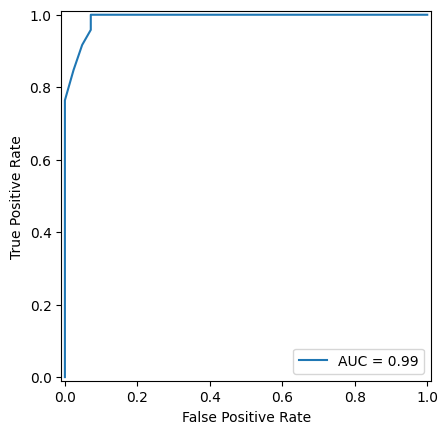

In [124]:
from sklearn.metrics import RocCurveDisplay

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()

print("ROC AUC:", roc_auc)

In [125]:
# ---------------------
# CHECK (DO NOT MODIFY)
# ---------------------

ROC_AUC_REF = 0.9910714285714286

assert abs(float(roc_auc) - ROC_AUC_REF) < 1e-12

print("✅ Q3.4(d) correct")

✅ Q3.4(d) correct


### **3.4.5 ROC Curve Interpretation**

What does the ROC curve represent in terms of model performance? Explain briefly. Write your answer below.



Answer: The ROC curve shows that the model has far more predictive power than a "dumb" classifier - almost perfectly separating classes. AUC of 0.99 means the model has a 99% probability that a randomly chosen positive is ranked higher than a randomly chosen negative.

# **Part III**
## Question 4: Regression + Feature Engineering

In this question, you will use the **California Housing** dataset.

- **Target**: `MedHouseVal`  
- **Features**: all remaining columns

You will:
1. Split the data into train/test.
2. Inject missing values *in training only* and impute them correctly.
3. Standardize features *fit on training only*.
4. Create nonlinear engineered features.
5. Compare Linear Regression performance **with vs without** engineered features.

In [126]:
# ------------
# Data Loading
# ------------

data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

# Separate features/target
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



### 4.1 Train/Test Split

Split the data into:
- 70% training, 30% test
- `random_state = 607`

Store your results in:

- `X_train`, `X_test`, `y_train`, `y_test`


In [127]:
X_train , X_test , y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=607)

print("X_train shape:", None if X_train is None else X_train.shape)
print("X_test shape:",  None if X_test  is None else X_test.shape)

X_train shape: (14448, 8)
X_test shape: (6192, 8)


In [128]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
assert isinstance(X_train, pd.DataFrame) and isinstance(X_test, pd.DataFrame)
assert isinstance(y_train, (pd.Series, np.ndarray)) and isinstance(y_test, (pd.Series, np.ndarray))
assert X_train.shape[0] > X_test.shape[0]
assert len(y_train) == X_train.shape[0]
assert len(y_test) == X_test.shape[0]


### 4.2 Introduce Missing Values and Impute

1. In the **training set only**, randomly set **5%** of values in the feature `AveRooms` to `NaN`.
2. Impute those missing values using the **mean of `AveRooms` computed from the training set only**.
3. After imputation, there should be no missing values left in `X_train["AveRooms"]`.

Store:
- `n_missing` (number of injected missing values)
- `train_averrooms_mean` (mean used for imputation, computed from training)


In [129]:
n_missing = int(0.05 * len(X_train))
missing_idx = np.random.choice(X_train.index, n_missing, replace=False)
X_train.loc[missing_idx, "AveRooms"] = np.nan
train_averrooms_mean = X_train["AveRooms"].mean()
X_train["AveRooms"].fillna(train_averrooms_mean, inplace=True)

print("Injected missing values in training AveRooms:", n_missing)
print("Training mean used for imputation:", train_averrooms_mean)


Injected missing values in training AveRooms: 722
Training mean used for imputation: 5.429382811305282


In [130]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
assert "AveRooms" in X_train.columns
assert isinstance(n_missing, int) and n_missing > 0
assert X_train["AveRooms"].isna().sum() == 0
assert np.isfinite(train_averrooms_mean)



### 4.3 Feature Scaling (Standardization)

Standardize all features using:

$$
z = \frac{x - \mu}{\sigma}
$$

- Fit the scaler **only on training data**
- Transform both training and test sets

Store:
- `scaler` (a fitted `StandardScaler`)
- `X_train_scaled` (NumPy array)
- `X_test_scaled` (NumPy array)


In [131]:

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled shape:", None if X_train_scaled is None else X_train_scaled.shape)
print("X_test_scaled shape:",  None if X_test_scaled  is None else X_test_scaled.shape)


X_train_scaled shape: (14448, 8)
X_test_scaled shape: (6192, 8)


In [132]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
assert isinstance(scaler, StandardScaler)
assert isinstance(X_train_scaled, np.ndarray) and isinstance(X_test_scaled, np.ndarray)
assert X_train_scaled.shape[0] == X_train.shape[0]
assert X_test_scaled.shape[0] == X_test.shape[0]

# Means of standardized training features should be ~0
train_means = X_train_scaled.mean(axis=0)
assert np.all(np.abs(train_means) < 1e-1)



### 4.4 Nonlinear Feature Engineering

Create the following new features **using the original (imputed) feature columns**:

1. `Rooms_per_Household = AveRooms / AveOccup`
2. `Bedrooms_per_Room = AveBedrms / AveRooms`
3. `MedInc_squared = (MedInc)^2`

Add them to both training and test sets.

Store:
- `X_train_fe`, `X_test_fe` as DataFrames including original features + engineered features


In [133]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

for df in [X_train_fe, X_test_fe]:
    df["Rooms_per_Household"] = df["AveRooms"] / df["AveOccup"]
    df["Bedrooms_per_Room"] = df["AveBedrms"] / df["AveRooms"]
    df["MedInc_squared"] = df["MedInc"] ** 2


print("New columns present (train):")
for col in ["Rooms_per_Household", "Bedrooms_per_Room", "MedInc_squared"]:
    print(f" - {col}: ", None if X_train_fe is None else (col in X_train_fe.columns))


New columns present (train):
 - Rooms_per_Household:  True
 - Bedrooms_per_Room:  True
 - MedInc_squared:  True


In [134]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
required_cols = {"Rooms_per_Household", "Bedrooms_per_Room", "MedInc_squared"}
assert isinstance(X_train_fe, pd.DataFrame) and isinstance(X_test_fe, pd.DataFrame)
assert required_cols.issubset(set(X_train_fe.columns))
assert required_cols.issubset(set(X_test_fe.columns))

assert np.isfinite(X_train_fe[list(required_cols)].to_numpy()).all()
assert np.isfinite(X_test_fe[list(required_cols)].to_numpy()).all()



### 4.5 Model Comparison (Linear Regression)

Fit **two** Linear Regression models:

1. Using **original features only**
2. Using **engineered features**

For each model, compute:
- Training MSE
- Test MSE

Store:
- `train_mse_original`, `test_mse_original`
- `train_mse_fe`, `test_mse_fe`


In [135]:
fit_original = LinearRegression()
fit_original.fit(X_train, y_train)

fit_fe = LinearRegression()
fit_fe.fit(X_train_fe, y_train)

train_mse_original = mean_squared_error(y_train, fit_original.predict(X_train))
test_mse_original  = mean_squared_error(y_test, fit_original.predict(X_test))

train_mse_fe = mean_squared_error(y_train, fit_fe.predict(X_train_fe))
test_mse_fe  = mean_squared_error(y_test, fit_fe.predict(X_test_fe))

print("Original features -> Train MSE:", train_mse_original, " Test MSE:", test_mse_original)
print("Engineered features -> Train MSE:", train_mse_fe, " Test MSE:", test_mse_fe)


Original features -> Train MSE: 0.5282275688252247  Test MSE: 0.5229211921973557
Engineered features -> Train MSE: 0.4396510204821858  Test MSE: 0.4852573725848018


In [136]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
for v in [train_mse_original, test_mse_original, train_mse_fe, test_mse_fe]:
    assert isinstance(v, float)
    assert np.isfinite(v) and v >= 0.0


# Part IV
## Question 5: Nonlinear Models: Naive Bayes and Support Vector Machines

In this question, you will work with a **challenging imbalanced binary classification** dataset generated using `make_classification`.

This dataset includes:
- correlated predictors,
- redundant features,
- label noise,
- class imbalance,

which makes it appropriate for comparing:
- **Gaussian Naive Bayes** (generative, independence assumption),
- **SVM (linear)**,
- **SVM (RBF)**.

In [137]:

# ----------------------------------------
# Data generation (run this cell)
# ----------------------------------------
X, y = make_classification(
    n_samples=4000,
    n_features=25,
    n_informative=8,
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    weights=[0.85, 0.15],
    class_sep=1.0,
    flip_y=0.05,
    random_state=607
)

X = pd.DataFrame(X, columns=[f"x{i+1}" for i in range(X.shape[1])])
y = pd.Series(y, name="y")

X.head()


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,-1.008827,-0.799199,0.648808,0.353251,-3.277477,-1.064745,-1.260413,2.011935,0.179048,-1.108091,...,2.697372,-3.202526,1.699815,0.732664,3.917327,-3.469030,0.165799,-0.322501,1.098726,-0.592410
1,2.066617,-2.568154,0.570426,-0.513337,2.009909,-0.479547,1.692521,-1.513710,0.552162,-1.445921,...,-1.612370,3.628845,0.618676,-1.158740,-4.871026,1.540493,1.036032,-0.109647,-1.848054,0.344856
2,1.174904,-1.065702,0.860457,-0.609825,-0.020617,-0.181921,2.108137,-0.477454,-0.315450,-0.702940,...,2.095224,-1.141962,0.340984,-1.209637,-0.123036,1.791961,-0.983080,-2.160556,4.108751,-0.791702
3,0.082243,-0.111756,-1.061655,1.504409,-1.523796,0.061934,3.506181,0.308654,-0.392627,0.387948,...,-1.923903,-0.829129,-0.380336,-2.545524,1.821995,4.901554,-1.205862,-1.295147,4.367899,-0.296280
4,0.907007,3.118968,0.586441,-0.426039,-1.534210,0.316316,-2.747934,-0.819677,0.097053,0.578950,...,0.699855,1.182017,-2.918099,-5.567572,3.881645,-10.950817,1.401225,1.844221,1.344441,-0.799053



## 5.1 Train/Test Split and Class Balance

1. Split into:
   - 70% training, 30% test  
   - `random_state=607`  
   - `stratify=y`

2. Compute:
   - `train_pos_rate` = proportion of class 1 in training
   - `test_pos_rate`  = proportion of class 1 in test


In [138]:
X_train , X_test , y_train, y_test = train_test_split (X, y, test_size=0.3, random_state=607, stratify=y)
train_pos_rate = y_train.mean()
test_pos_rate = y_test.mean()

print("Train positive rate:", train_pos_rate)
print("Test positive rate:",  test_pos_rate)


Train positive rate: 0.16857142857142857
Test positive rate: 0.16833333333333333


In [139]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
assert isinstance(X_train, pd.DataFrame) and isinstance(X_test, pd.DataFrame)
assert isinstance(y_train, pd.Series) and isinstance(y_test, pd.Series)

assert X_train.shape[0] > X_test.shape[0]
assert len(y_train) == X_train.shape[0]
assert len(y_test) == X_test.shape[0]

assert isinstance(train_pos_rate, float) and isinstance(test_pos_rate, float)
assert 0 < train_pos_rate < 1 and 0 < test_pos_rate < 1
assert abs(train_pos_rate - test_pos_rate) < 0.01



## 5.2 Gaussian Naive Bayes (Baseline)

1. Fit **GaussianNB** on the training set.
2. Predict **class labels** on the test set.
3. Compute and store:
   - `acc_nb`
   - `f1_nb` (use `average="binary"`)
   - confusion matrix entries: `tn_nb, fp_nb, fn_nb, tp_nb`


In [140]:

model_gnb = GaussianNB()
model_gnb.fit(X_train, y_train)
preds_gnb = model_gnb.predict(X_test)

acc_nb = accuracy_score(y_test, preds_gnb)
f1_nb = f1_score(y_test, preds_gnb, average="binary")
tn_nb, fp_nb, fn_nb, tp_nb = confusion_matrix(y_test, preds_gnb).ravel()

print("GaussianNB -> Accuracy:", acc_nb)
print("GaussianNB -> F1:", f1_nb)
print("GaussianNB -> TN, FP, FN, TP:", tn_nb, fp_nb, fn_nb, tp_nb)

cm = confusion_matrix(y_test, preds_gnb)




GaussianNB -> Accuracy: 0.8708333333333333
GaussianNB -> F1: 0.5706371191135734
GaussianNB -> TN, FP, FN, TP: 942 56 99 103


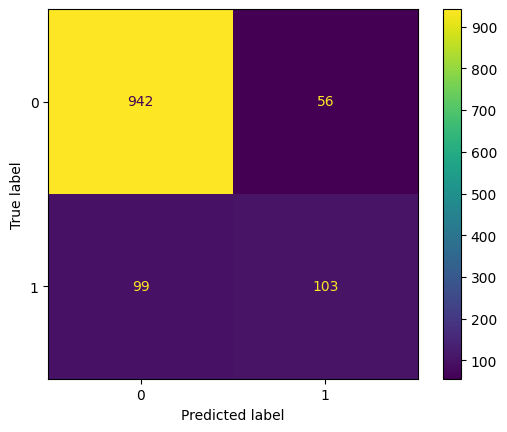

In [141]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot()
plt.show()

In [142]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
for v in [acc_nb, f1_nb]:
    assert isinstance(v, float)
    assert 0.0 <= v <= 1.0

for v in [tn_nb, fp_nb, fn_nb, tp_nb]:
    assert isinstance(v, (int, np.integer))

assert (tn_nb + fp_nb + fn_nb + tp_nb) == len(y_test)



## 5.3 Linear SVM (with Scaling)

1. Fit a pipeline: `StandardScaler()` + `SVC(kernel="linear")`
2. Predict test labels.
3. Compute and store:
   - `acc_svm_lin`
   - `f1_svm_lin`
   - confusion matrix entries: `tn_lin, fp_lin, fn_lin, tp_lin`


In [143]:
svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel="linear"))
svm_pipeline.fit(X_train, y_train)
preds_svm_lin = svm_pipeline.predict(X_test)

acc_svm_lin = accuracy_score(y_test, preds_svm_lin)
f1_svm_lin = f1_score(y_test, preds_svm_lin, average="binary")
tn_lin, fp_lin, fn_lin, tp_lin = confusion_matrix(y_test, preds_svm_lin).ravel()

print("Linear SVM -> Accuracy:", acc_svm_lin)
print("Linear SVM -> F1:", f1_svm_lin)
print("Linear SVM -> TN, FP, FN, TP:", tn_lin, fp_lin, fn_lin, tp_lin)


Linear SVM -> Accuracy: 0.8958333333333334
Linear SVM -> F1: 0.5674740484429066
Linear SVM -> TN, FP, FN, TP: 993 5 120 82


In [144]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
for v in [acc_svm_lin, f1_svm_lin]:
    assert isinstance(v, float)
    assert 0.0 <= v <= 1.0

for v in [tn_lin, fp_lin, fn_lin, tp_lin]:
    assert isinstance(v, (int, np.integer))

assert (tn_lin + fp_lin + fn_lin + tp_lin) == len(y_test)



## 5.4 RBF SVM (Default Hyperparameters)

1. Fit a pipeline: `StandardScaler()` + `SVC(kernel="rbf")`
2. Predict test labels.
3. Compute and store:
   - `acc_svm_rbf`
   - `f1_svm_rbf`


In [145]:
svm_rbf_pipeline = make_pipeline(StandardScaler(), SVC(kernel="rbf"))
svm_rbf_pipeline.fit(X_train, y_train)
preds_svm_rbf = svm_rbf_pipeline.predict(X_test)

acc_svm_rbf = accuracy_score(y_test, preds_svm_rbf)
f1_svm_rbf = f1_score(y_test, preds_svm_rbf, average="binary")
tn_rbf, fp_rbf, fn_rbf, tp_rbf = confusion_matrix(y_test, preds_svm_rbf).ravel()

print("RBF SVM -> Accuracy:", acc_svm_rbf)
print("RBF SVM -> F1:", f1_svm_rbf)
print("RBF SVM -> TN, FP, FN, TP:", tn_rbf, fp_rbf, fn_rbf, tp_rbf)


RBF SVM -> Accuracy: 0.935
RBF SVM -> F1: 0.7650602409638554
RBF SVM -> TN, FP, FN, TP: 995 3 75 127


In [146]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
for v in [acc_svm_rbf, f1_svm_rbf]:
    assert isinstance(v, float)
    assert 0.0 <= v <= 1.0



## 5.5 Hyperparameter Tuning for RBF SVM (Validation-Based)

Create a validation split from the training data:
- 80% sub-train, 20% validation
- `random_state=607`
- `stratify=y_train`

Grid:
```python
C_grid     = [0.1, 1, 10]
gamma_grid = [0.01, 0.1, 1]
```

Choose (C, gamma) maximizing **validation F1**. Then refit on full training and report:
- `best_C`, `best_gamma`
- `acc_best`, `f1_best`


In [147]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
     X_train, y_train, test_size=0.2, random_state=607, stratify=y_train)

C_grid = [0.1, 1, 10]
gamma_grid = [0.01, 0.1, 1]

In [148]:
best_C = None
best_gamma = None
f1_best = -1

for C in C_grid:
    for gamma in gamma_grid:
        model = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=C, gamma=gamma))

        model.fit(X_train_sub, y_train_sub)
        preds_val = model.predict(X_val)

        val_f1 = f1_score(y_val, preds_val, average="binary")

        if val_f1 > f1_best:
            f1_best = val_f1
            best_C = C
            best_gamma = gamma

best_model = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=best_C, gamma=best_gamma))

best_model.fit(X_train, y_train)
preds_best = best_model.predict(X_test)

acc_best = accuracy_score(y_test, preds_best)
f1_best = f1_score(y_test, preds_best, average="binary")

print("best_C:", best_C)
print("best_gamma:", best_gamma)
print("acc_best", acc_best)
print("f1_best", f1_best)


best_C: 10
best_gamma: 0.01
acc_best 0.9325
f1_best 0.7624633431085044


In [149]:
scores = []

for C in C_grid:
    for gamma in gamma_grid:
        model = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=C, gamma=gamma))
        model.fit(X_train_sub, y_train_sub)
        preds_val = model.predict(X_val)
        val_f1 = f1_score(y_val, preds_val, average="binary")

        scores.append([C, gamma, val_f1])

scores

[[0.1, 0.01, 0.041666666666666664],
 [0.1, 0.1, 0.0],
 [0.1, 1, 0.0],
 [1, 0.01, 0.53125],
 [1, 0.1, 0.6376811594202898],
 [1, 1, 0.0],
 [10, 0.01, 0.7435897435897436],
 [10, 0.1, 0.7236842105263158],
 [10, 1, 0.0]]

In [150]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
assert best_C in [0.1, 1, 10]
assert best_gamma in [0.01, 0.1, 1]

for v in [acc_best, f1_best]:
    assert isinstance(v, float)
    assert 0.0 <= v <= 1.0



## 5.6 ROC Curve: Baseline vs Tuned RBF SVM

1. Fit two pipelines:
   - baseline: `StandardScaler()` + `SVC(kernel="rbf")`
   - tuned: `StandardScaler()` + `SVC(kernel="rbf", C=best_C, gamma=best_gamma)`

2. Use `.decision_function(X_test)` for scores.
3. Compute:
   - `auc_rbf_default`
   - `auc_rbf_tuned`
4. Plot both ROC curves on the same figure.


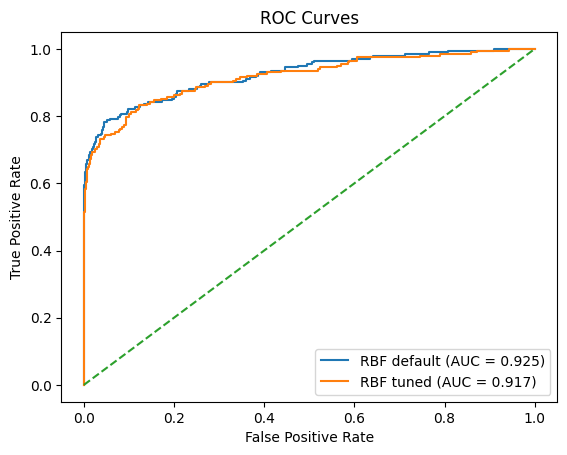

In [151]:
# baseline model
rbf_default = make_pipeline(StandardScaler(), SVC(kernel="rbf"))
rbf_default.fit(X_train, y_train)

scores_default = rbf_default.decision_function(X_test)
auc_rbf_default = roc_auc_score(y_test, scores_default)

fpr_default, tpr_default, _ = roc_curve(y_test, scores_default)


# tuned model
rbf_tuned = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=best_C, gamma=best_gamma))
rbf_tuned.fit(X_train, y_train)

scores_tuned = rbf_tuned.decision_function(X_test)
auc_rbf_tuned = roc_auc_score(y_test, scores_tuned)

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, scores_tuned)


# plot ROC curves
plt.figure()

plt.plot(fpr_default, tpr_default, label=f"RBF default (AUC = {auc_rbf_default:.3f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"RBF tuned (AUC = {auc_rbf_tuned:.3f})")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

In [152]:

# ------------------------
# CHECK (DO NOT MODIFY)
# ------------------------
for v in [auc_rbf_default, auc_rbf_tuned]:
    assert isinstance(v, float)
    assert 0.0 <= v <= 1.0



## 5.7 Short Interpretation

Answer all:
1. Which model had the best **test F1**?  
2. Why scaling matters for SVM but not as much for GaussianNB?  
3. Why might GaussianNB underperform on this dataset?  
4. Why can accuracy be misleading with class imbalance?  

Write your answer below:


1. RBF SVM had the best test F1 score. Likely that the non linear kernel can capture more complex decision boundaries.
2. Because it is a distance based model that relies on margins in feature space. So different feature scales distort distances. Gaussian NB models each feature independently.
3. Because features are highly correlated which is against the independence assumption of Gaussian NB.
4. High accuracy can be achieved in an imbalanced dataset simply by predicting the majority class. So the model can have high accuracy but terrible recall and/or precision.